## EDA Assignment

##  Import Required Libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


### 1: Import Dataset & Display First 10 Rows

In [43]:
df = pd.read_csv('Auto_Sales.csv')
df.head(10)

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,SALES,ORDERDATE,DAYS_SINCE_LASTORDER,STATUS,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,ADDRESSLINE1,CITY,POSTALCODE,COUNTRY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2871.00,24-02-2018,828,Shipped,Motorcycles,95,S10_1678,Land of Toys Inc.,897 Long Airport Avenue,NYC,10022,USA,Yu,Kwai,Small
1,10121,34,81.35,2765.90,07-05-2018,757,Shipped,Motorcycles,95,S10_1678,Reims Collectables,59 rue de l'Abbaye,Reims,51100,France,Henriot,Paul,Small
2,10134,41,94.74,3884.34,01-07-2018,703,Shipped,Motorcycles,95,S10_1678,Lyon Souveniers,27 rue du Colonel Pierre Avia,Paris,75508,France,Da Cunha,Daniel,Medium
3,10145,45,83.26,3746.70,25-08-2018,649,Shipped,Motorcycles,95,S10_1678,Toys4GrownUps.com,78934 Hillside Dr.,Pasadena,90003,USA,Young,Julie,Medium
4,10168,36,96.66,3479.76,28-10-2018,586,Shipped,Motorcycles,95,S10_1678,Technics Stores Inc.,9408 Furth Circle,Burlingame,94217,USA,Hirano,Juri,Medium
5,10180,29,86.13,2497.77,11-11-2018,573,Shipped,Motorcycles,95,S10_1678,Daedalus Designs Imports,"184, chausse de Tournai",Lille,59000,France,Rance,Martine,Small
6,10188,48,114.84,5512.32,18-11-2018,567,Shipped,Motorcycles,95,S10_1678,Herkku Gifts,"Drammen 121, PR 744 Sentrum",Bergen,N 5804,Norway,Oeztan,Veysel,Medium
7,10211,41,114.84,4708.44,15-01-2019,510,Shipped,Motorcycles,95,S10_1678,Auto Canal Petit,"25, rue Lauriston",Paris,75016,France,Perrier,Dominique,Medium
8,10223,37,107.18,3965.66,20-02-2019,475,Shipped,Motorcycles,95,S10_1678,"Australian Collectors, Co.",636 St Kilda Road,Melbourne,3004,Australia,Ferguson,Peter,Medium
9,10237,23,101.44,2333.12,05-04-2019,432,Shipped,Motorcycles,95,S10_1678,Vitachrome Inc.,2678 Kingston Rd.,NYC,10022,USA,Frick,Michael,Small


In [45]:
print("Shape of dataset:", df.shape)

Shape of dataset: (2747, 18)


### 2: Check Data Types

In [46]:
df.dtypes

ORDERNUMBER               int64
QUANTITYORDERED           int64
PRICEEACH               float64
SALES                   float64
ORDERDATE                object
DAYS_SINCE_LASTORDER      int64
STATUS                   object
PRODUCTLINE              object
MSRP                      int64
PRODUCTCODE              object
CUSTOMERNAME             object
ADDRESSLINE1             object
CITY                     object
POSTALCODE               object
COUNTRY                  object
CONTACTLASTNAME          object
CONTACTFIRSTNAME         object
DEALSIZE                 object
dtype: object

### 3: Check & Remove Duplicate Records

In [47]:
print("Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)


Duplicate Rows: 0
Shape after removing duplicates: (2747, 18)


### 4: Outlier Detection Using IQR Method

In [16]:
num_cols = df.select_dtypes(include=np.number)

for col in num_cols.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(col, "Outliers:", outliers.shape[0])


ORDERNUMBER Outliers: 0
QUANTITYORDERED Outliers: 8
PRICEEACH Outliers: 33
SALES Outliers: 79
DAYS_SINCE_LASTORDER Outliers: 0
MSRP Outliers: 26


### 5: Unique Customers & Countries

In [17]:
print("Unique Customers:", df['CUSTOMERNAME'].nunique())
print("Unique Countries:", df['COUNTRY'].nunique())


Unique Customers: 89
Unique Countries: 19


### 6: Convert ORDERDATE & Extract Year & Month

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Auto_Sales.csv')

df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'], dayfirst=True)
df['Year'] = df['ORDERDATE'].dt.year
df['Month'] = df['ORDERDATE'].dt.month

df[['ORDERDATE', 'Year', 'Month']].head()


,ORDERDATE,Year,Month
0,2018-02-24,2018,2
1,2018-05-07,2018,5
2,2018-07-01,2018,7
3,2018-08-25,2018,8
4,2018-10-28,2018,10


### 7: Monthly Sales Trend

In [21]:
monthly_sales = df.groupby(['Year','Month'])['SALES'].sum().reset_index()
monthly_sales.head()


,Year,Month,SALES
0,2018,1,129753.60
1,2018,2,140836.19
2,2018,3,155809.32
3,2018,4,201609.55
4,2018,5,192673.11


### 8: Plot Monthly Sales Trend

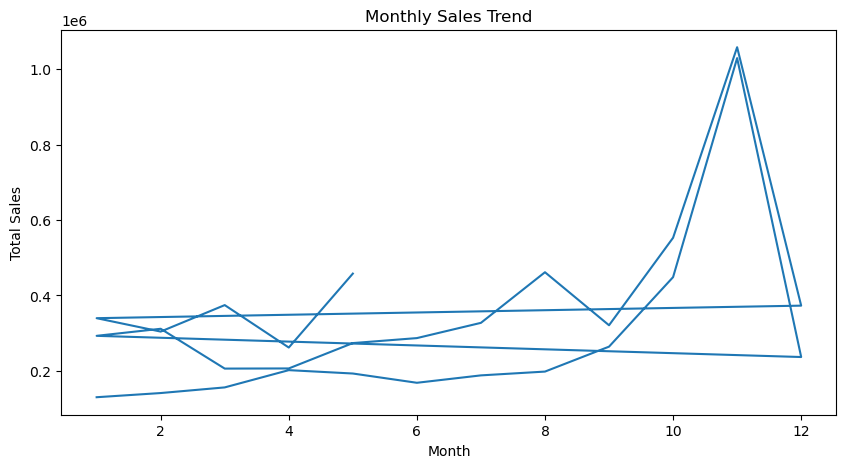

In [22]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales['Month'], monthly_sales['SALES'])
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Monthly Sales Trend')
plt.show()


### 9: Total Sales by Country & Top 3 Countries

In [23]:
country_sales = df.groupby('COUNTRY')['SALES'].sum().sort_values(ascending=False)
country_sales.head(3)


COUNTRY
USA       3355575.69
Spain     1215686.92
France    1110916.52
Name: SALES, dtype: float64

### 10: Average Order Value by DEALSIZE

In [9]:
df.groupby('DEALSIZE')['SALES'].mean()


DEALSIZE
Large     8282.607895
Medium    4396.761653
Small     2062.627480
Name: SALES, dtype: float64

### 11: Items Sold Above MSRP

In [37]:
above_msrp = df[df['PRICEEACH'] > df['MSRP']]
print("Items Sold Above MSRP:", above_msrp.shape[0])


Items Sold Above MSRP: 1398


### 12: Bar Chart – Total Sales by Product Line

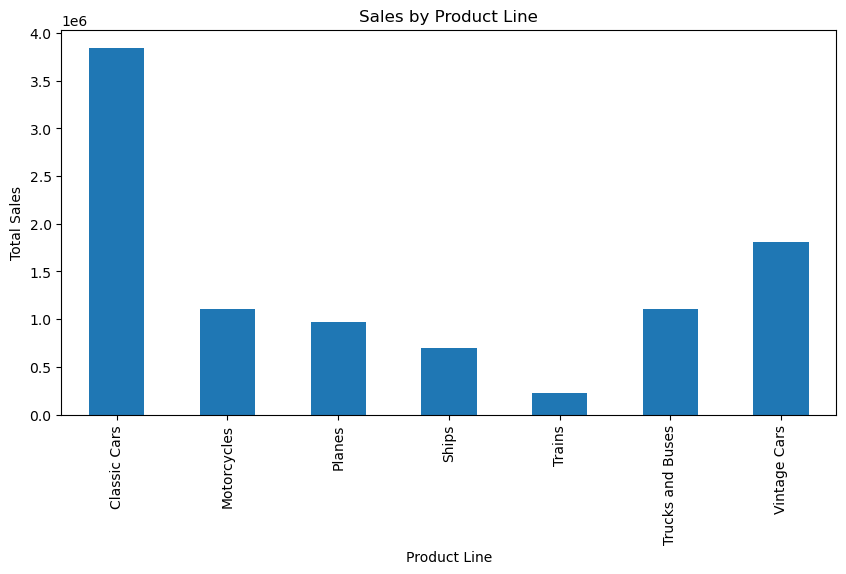

In [11]:
df.groupby('PRODUCTLINE')['SALES'].sum().plot(kind='bar', figsize=(10,5))
plt.xlabel('Product Line')
plt.ylabel('Total Sales')
plt.title('Sales by Product Line')
plt.show()


### 13: Correlation Matrix & Heatmap

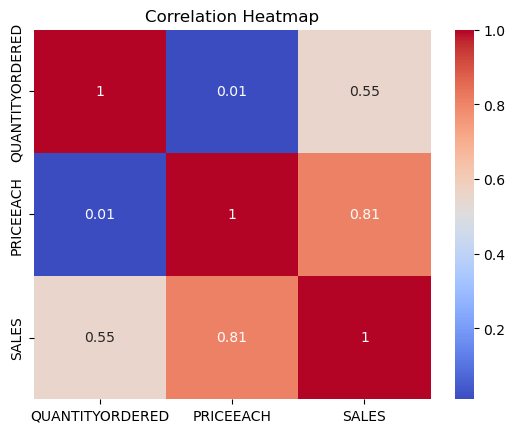

In [24]:
corr = df[['QUANTITYORDERED','PRICEEACH','SALES']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


### 14: Customers with Above Average Days Since Last Order

In [29]:
avg_days = df['DAYS_SINCE_LASTORDER'].mean()

df[df['DAYS_SINCE_LASTORDER'] > avg_days][
    ['CUSTOMERNAME','DAYS_SINCE_LASTORDER']
]


,CUSTOMERNAME,DAYS_SINCE_LASTORDER
922,Baane Mini Imports,1776
947,Danish Wholesale Imports,1788
972,Euro Shopping Channel,1824
973,Motor Mint Distributors Inc.,1787
974,"La Corne D'abondance, Co.",1766
...,...,...
2742,Euro Shopping Channel,2924
2743,"Oulu Toy Supplies, Inc.",2865
2744,Euro Shopping Channel,2836
2745,Alpha Cognac,2810


### 15: Customers with More Than One Order

In [34]:
multi_orders = df.groupby('CUSTOMERNAME')['ORDERNUMBER'].count().reset_index(name='Order_Count')
multi_orders = multi_orders[multi_orders['Order_Count'] > 1]
print(multi_orders)


                   CUSTOMERNAME  Order_Count
0                AV Stores, Co.           51
1                  Alpha Cognac           20
2            Amica Models & Co.           26
3       Anna's Decorations, Ltd           46
4             Atelier graphique            7
..                          ...          ...
84              Vida Sport, Ltd           31
85              Vitachrome Inc.           25
86     Volvo Model Replicas, Co           19
87  West Coast Collectables Co.           13
88            giftsbymail.co.uk           26

[89 rows x 2 columns]


### 16: Check Missing Values

In [36]:
df.isnull().sum()


ORDERNUMBER             0
QUANTITYORDERED         0
PRICEEACH               0
SALES                   0
ORDERDATE               0
DAYS_SINCE_LASTORDER    0
STATUS                  0
PRODUCTLINE             0
MSRP                    0
PRODUCTCODE             0
CUSTOMERNAME            0
ADDRESSLINE1            0
CITY                    0
POSTALCODE              0
COUNTRY                 0
CONTACTLASTNAME         0
CONTACTFIRSTNAME        0
DEALSIZE                0
Year                    0
Month                   0
dtype: int64

### 17: Create Numerical & Categorical DataFrames

In [37]:
import pandas as pd
import numpy as np

# Separate numerical and categorical columns
num_df = df.select_dtypes(include=np.number)
cat_df = df.select_dtypes(include='object')

# Display as tables
print("Numerical DataFrame:")
display(num_df.head())

print("\nCategorical DataFrame:")
display(cat_df.head())


Numerical DataFrame:


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,SALES,DAYS_SINCE_LASTORDER,MSRP,Year,Month
0,10107,30,95.70,2871.00,828,95,2018,2
1,10121,34,81.35,2765.90,757,95,2018,5
2,10134,41,94.74,3884.34,703,95,2018,7
3,10145,45,83.26,3746.70,649,95,2018,8
4,10168,36,96.66,3479.76,586,95,2018,10



Categorical DataFrame:


,STATUS,PRODUCTLINE,PRODUCTCODE,CUSTOMERNAME,ADDRESSLINE1,CITY,POSTALCODE,COUNTRY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,Shipped,Motorcycles,S10_1678,Land of Toys Inc.,897 Long Airport Avenue,NYC,10022,USA,Yu,Kwai,Small
1,Shipped,Motorcycles,S10_1678,Reims Collectables,59 rue de l'Abbaye,Reims,51100,France,Henriot,Paul,Small
2,Shipped,Motorcycles,S10_1678,Lyon Souveniers,27 rue du Colonel Pierre Avia,Paris,75508,France,Da Cunha,Daniel,Medium
3,Shipped,Motorcycles,S10_1678,Toys4GrownUps.com,78934 Hillside Dr.,Pasadena,90003,USA,Young,Julie,Medium
4,Shipped,Motorcycles,S10_1678,Technics Stores Inc.,9408 Furth Circle,Burlingame,94217,USA,Hirano,Juri,Medium


### 1: Rename Columns

In [40]:
df.rename(columns={
    'ORDERNUMBER':'order_number',
    'QUANTITYORDERED':'qty_ordered'
}, inplace=True)
df.columns


Index(['order_number', 'qty_ordered', 'PRICEEACH', 'SALES', 'ORDERDATE',
       'DAYS_SINCE_LASTORDER', 'STATUS', 'PRODUCTLINE', 'MSRP', 'PRODUCTCODE',
       'CUSTOMERNAME', 'ADDRESSLINE1', 'CITY', 'POSTALCODE', 'COUNTRY',
       'CONTACTLASTNAME', 'CONTACTFIRSTNAME', 'DEALSIZE', 'Year', 'Month'],
      dtype='object')

### 19: Feature Scaling (Standard Scaler)

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_df = pd.DataFrame(
    scaler.fit_transform(num_df),
    columns=num_df.columns
)
scaled_df.head()


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,SALES,DAYS_SINCE_LASTORDER,MSRP,Year,Month
0,-1.662968,-0.522831,-0.128440,-0.370956,-1.134233,-0.14191,-1.181266,-1.396082
1,-1.510563,-0.113010,-0.469823,-0.428119,-1.220910,-0.14191,-1.181266,-0.572170
2,-1.369045,0.604176,-0.151278,0.180185,-1.286834,-0.14191,-1.181266,-0.022895
3,-1.249299,1.013997,-0.424384,0.105325,-1.352757,-0.14191,-1.181266,0.251743
4,-0.998920,0.091900,-0.105602,-0.039860,-1.429668,-0.14191,-1.181266,0.801018


### 20: Skewness & Transformation

In [39]:
skewness = num_df.skew()

def skew_tag(x):
    if abs(x) < 0.5:
        return "Low Skewed"
    elif abs(x) < 1:
        return "Moderately Skewed"
    else:
        return "Highly Skewed"

skew_df = pd.DataFrame({
    'Skewness': skewness,
    'Category': skewness.apply(skew_tag)
})

skew_df



,Skewness,Category
ORDERNUMBER,-0.006995,Low Skewed
QUANTITYORDERED,0.369286,Low Skewed
PRICEEACH,0.697222,Moderately Skewed
SALES,1.155940,Highly Skewed
DAYS_SINCE_LASTORDER,-0.002983,Low Skewed
MSRP,0.575646,Moderately Skewed
Year,0.255765,Low Skewed
Month,-0.262844,Low Skewed
